In [1]:
!pip install kagglehub
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Download latest version
path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")
df = pd.read_csv("amazon_sales_dataset.csv")



C:\Users\aless\PycharmProjects\Amazon_Sales_Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [5]:
prod_cat = df.groupby(["product_category", "customer_region", "payment_method"])[["price", "discount_percent","quantity_sold", "total_revenue", "rating", "review_count",	"discounted_price"]].sum().reset_index()
prod_cat.head()

,product_category,customer_region,payment_method,price,discount_percent,quantity_sold,total_revenue,rating,review_count,discounted_price
0,Beauty,Asia,Cash on Delivery,108696.09,5855,1306,283496.27,1297.2,104262,93881.51
1,Beauty,Asia,Credit Card,106261.25,5425,1180,270807.84,1176.9,101449,92222.66
2,Beauty,Asia,Debit Card,110268.99,5465,1248,291431.42,1214.2,102648,96188.86
3,Beauty,Asia,UPI,99532.77,5280,1185,248354.32,1239.1,105275,86654.16
4,Beauty,Asia,Wallet,113298.44,5985,1398,307827.07,1322.2,109478,98428.77


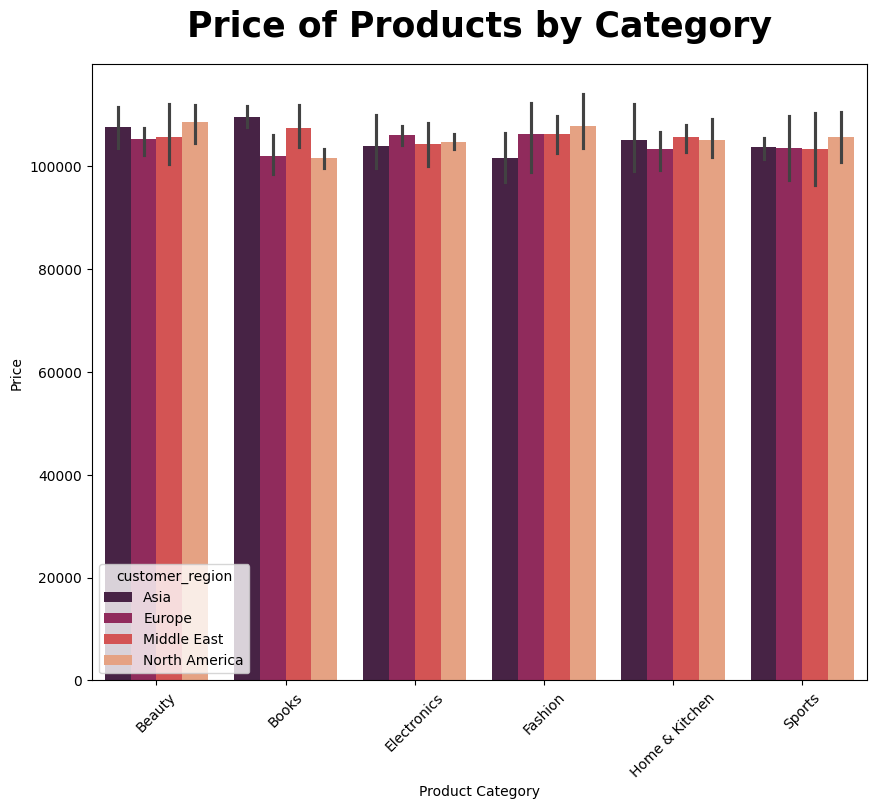

In [6]:
plt.figure(figsize=(10,8))
sns.barplot(prod_cat, x="product_category", y="price", hue="customer_region", palette="rocket")
plt.title("Price of Products by Category", fontsize=25, fontweight="bold", pad=20)
plt.xticks(rotation=45)
plt.xlabel("Product Category")
plt.ylabel("Price")
plt.show()

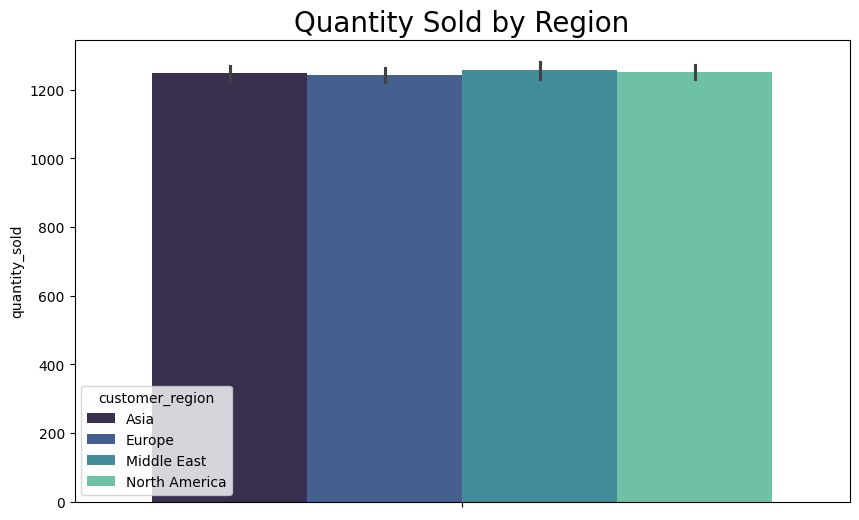

In [8]:
plt.figure(figsize=(10,6))
sns.barplot(prod_cat, hue="customer_region", y="quantity_sold", palette="mako")
plt.title("Quantity Sold by Region", fontsize=20)
plt.show()

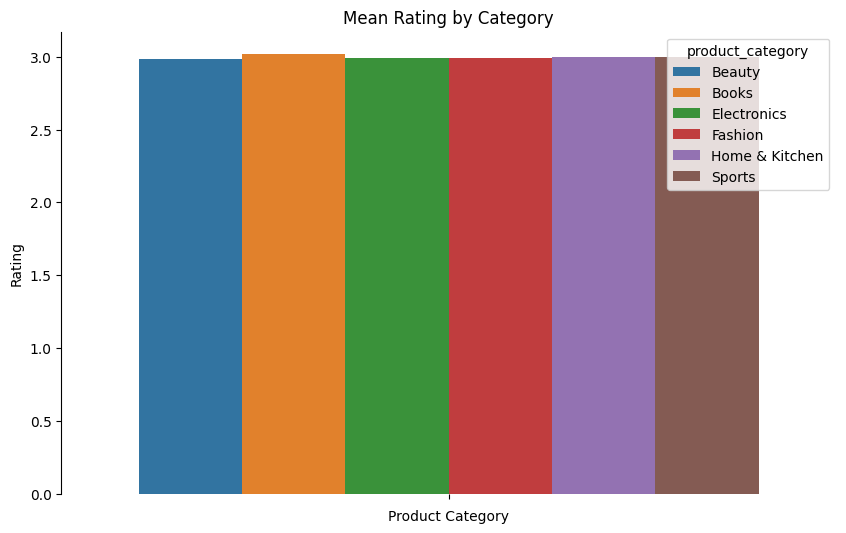

In [53]:
rating = df.groupby("product_category")["rating"].mean().reset_index()
plt.figure(figsize=(10,6))
ax = sns.barplot(rating, hue="product_category", y="rating")
ax.spines[["top", "right", "bottom"]].set_visible(False)
plt.title("Mean Rating by Category")
plt.xlabel("Product Category")
plt.ylabel("Rating")
plt.show()


In [10]:
disc = df.groupby("payment_method")[["discounted_price", "quantity_sold", "total_revenue"]].sum().reset_index()
disc.head()

,payment_method,discounted_price,quantity_sold,total_revenue
0,Cash on Delivery,2174342.02,29881,6546386.94
1,Credit Card,2166319.07,29875,6540087.16
2,Debit Card,2191386.04,29857,6522019.73
3,UPI,2201665.06,30035,6579441.44
4,Wallet,2210616.10,30322,6678638.47


Text(0, 0.5, 'Quantity Sold')

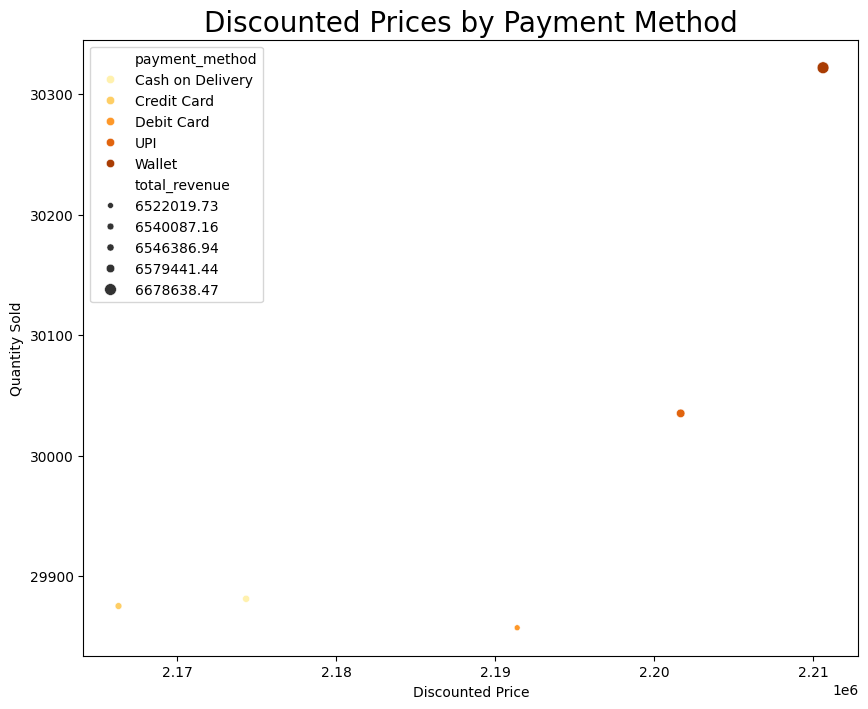

In [48]:
plt.figure(figsize=(10,8))
sns.scatterplot(disc, x="discounted_price", y="quantity_sold", hue="payment_method", size="total_revenue", palette="YlOrBr")
plt.title("Discounted Prices by Payment Method", fontsize=20)
plt.xlabel("Discounted Price")
plt.legend(loc="upper left")
plt.ylabel("Quantity Sold")

In [12]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [39]:
new_df = df.copy()
new_df["order_date"] = pd.to_datetime(new_df["order_date"]).dt.year
order = new_df.groupby(["order_date", "product_category"])[["total_revenue", "review_count", "discounted_price"]].sum().reset_index()

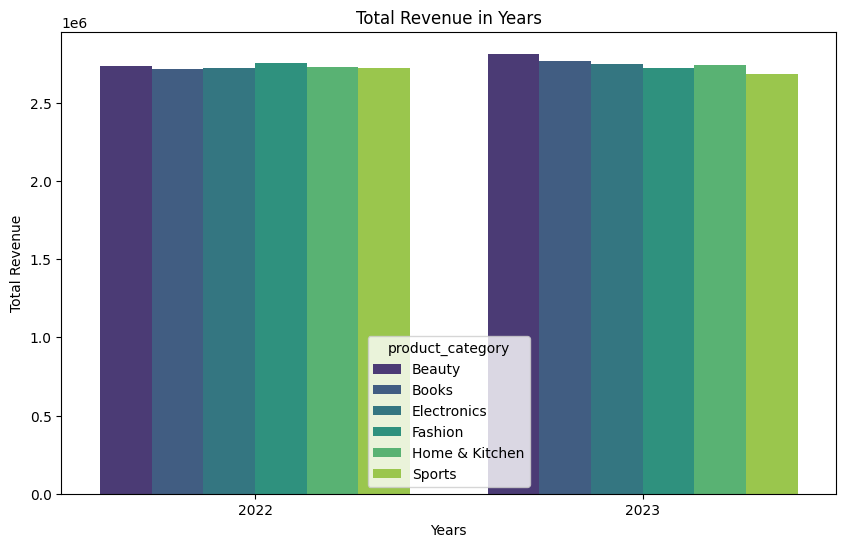

In [46]:
plt.figure(figsize=(10,6))
ax = sns.barplot(order, x="order_date", y="total_revenue", hue="product_category", palette="viridis")
plt.title("Total Revenue in Years")
plt.xlabel("Years")
plt.ylabel("Total Revenue")
plt.show()

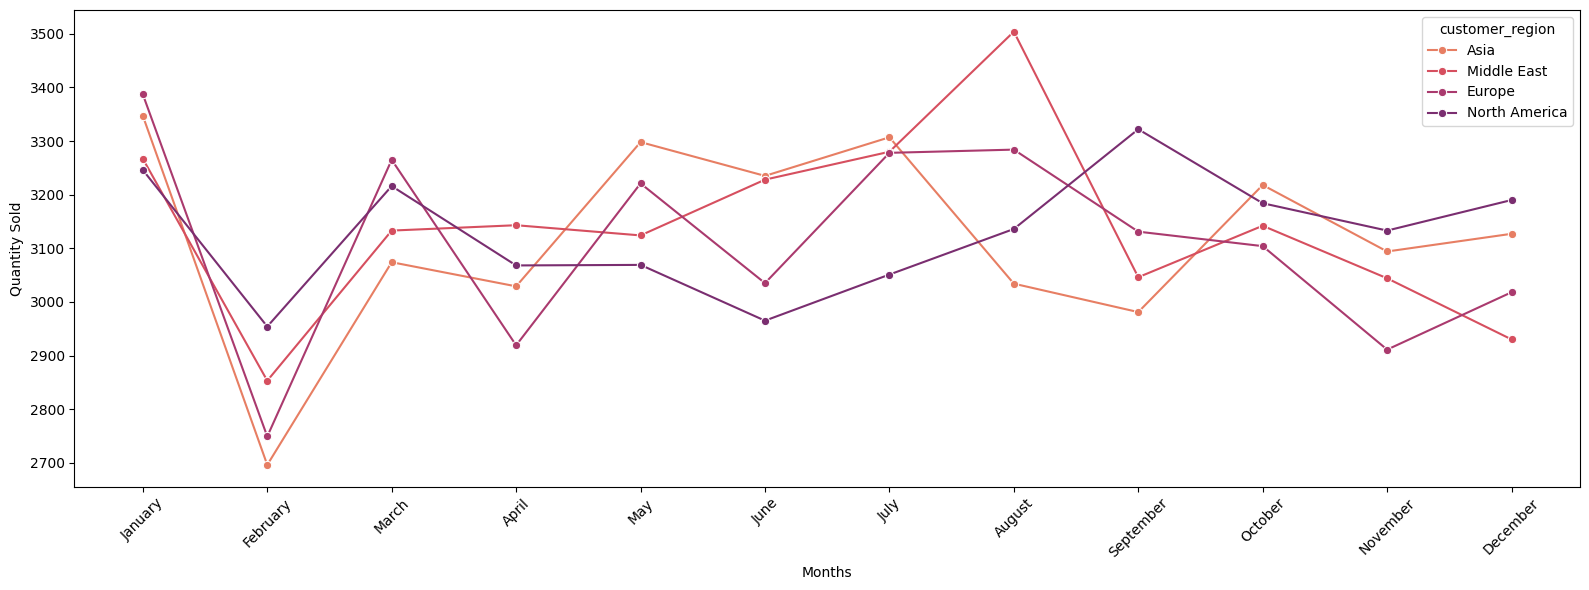

In [132]:
m_df = df.sort_values(by="order_date" ,ascending=True).copy()
m_df["order_date"] = pd.to_datetime(m_df["order_date"]).dt.month_name()
m= m_df.groupby(["order_date", "customer_region"], sort=False)[["quantity_sold", "total_revenue"]].sum().reset_index()

plt.figure(figsize=(16,6))
sns.lineplot(m, x="order_date", y="quantity_sold", hue="customer_region", marker='o', palette="flare")
plt.xlabel("Months")
plt.xticks(rotation=45)

plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()
